In [51]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ Basic imports successful!")

try:
    from sklearn.datasets import fetch_california_housing
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    print("✓ sklearn imports successful!")
except Exception as e:
    print(f"✗ Error with sklearn: {e}")

✓ Basic imports successful!
✓ sklearn imports successful!


In [52]:
print("="*60)
print("ATTEMPTING TO LOAD CALIFORNIA HOUSING DATASET...")
print("="*60)

try:
    california = fetch_california_housing()

    X = pd.DataFrame(california.data, columns=california.feature_names)
    y = california.target
    
    print("✓ Dataset loaded successfully!")
    print(f"\nDataset shape: {X.shape}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Number of samples: {X.shape[0]}")
    
    print("\nFeature names:")
    for i, col in enumerate(X.columns, 1):
        print(f"  {i}. {col}")
    
    print(f"\nTarget (y) shape: {y.shape}")
    
    # Show first 2 rows
    print("\nFirst 2 rows of features:")
    print(X.head(2))
    
    print(f"\nFirst 5 target values: {y[:5]}")
    
except Exception as e:
    print(f"\n✗ Error loading dataset: {e}")
    print("\nTrying backup dataset...")
    
    # Backup: Create synthetic data
    np.random.seed(42)
    n_samples = 1000
    X = pd.DataFrame({
        'Income': np.random.normal(50000, 15000, n_samples),
        'Age': np.random.randint(20, 70, n_samples),
        'Rooms': np.random.randint(1, 6, n_samples),
        'Distance': np.random.uniform(1, 20, n_samples)
    })
    y = 20000 + 300*X['Income']/1000 + 5000*X['Rooms'] + np.random.normal(0, 10000, n_samples)
    
    print("✓ Created synthetic dataset as backup")
    print(f"Shape: {X.shape}")
    print("Features:", list(X.columns))

print("\n" + "="*60)
print("CELL 2 COMPLETE")
print("="*60)

ATTEMPTING TO LOAD CALIFORNIA HOUSING DATASET...

✗ Error loading dataset: <urlopen error Tunnel connection failed: 403 Forbidden>

Trying backup dataset...
✓ Created synthetic dataset as backup
Shape: (1000, 4)
Features: ['Income', 'Age', 'Rooms', 'Distance']

CELL 2 COMPLETE


VISUALIZING OUR SYNTHETIC DATASET


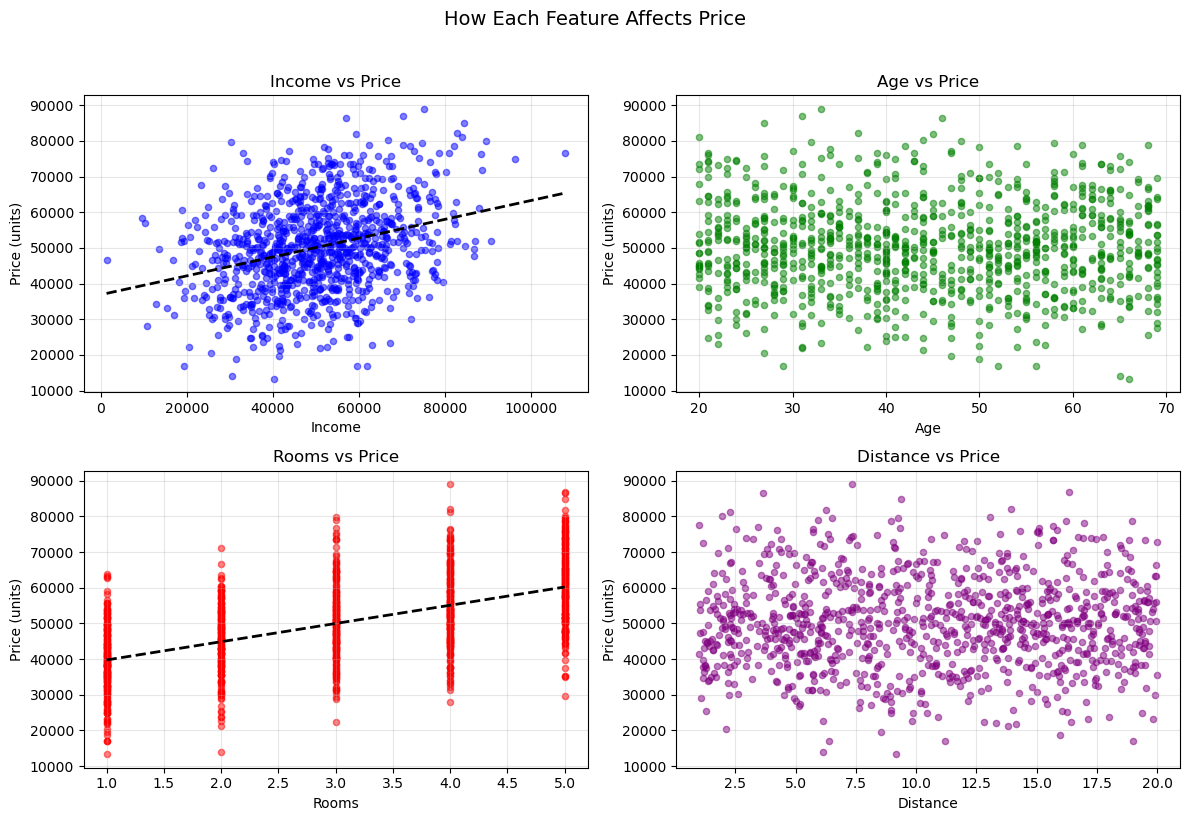


WHAT YOU SHOULD SEE:
✓ Income ↑ → Price ↑ (clear upward trend)
✓ Rooms ↑ → Price ↑ (stepped pattern - rooms are whole numbers)
✗ Age → No clear relationship (random scatter)
✗ Distance → No clear relationship (random scatter)

DATASET SUMMARY:
• Samples: 1000 houses
• Features: ['Income', 'Age', 'Rooms', 'Distance']
• Price range: 13,302 to 88,994 units
• Average price: 50,151 units


In [55]:
print("="*60)
print("VISUALIZING OUR SYNTHETIC DATASET")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
# Without flatten: axes[0,0], axes[0,1], axes[1,0], axes[1,1] 
# With flatten: axes[0], axes[1], axes[2], axes[3]  ← easier to loop
# e.g;
# axes[0] # first graph (top-left)
# axes[1] # second graph (top-right)  
# axes[2] # third graph (bottom-left)
# axes[3] # fourth graph (bottom-right)
features = ['Income', 'Age', 'Rooms', 'Distance']
colors = ['blue', 'green', 'red', 'purple']
for i, feature in enumerate(features): # enumerate -> Just a shortcut to get index+value together.
    ax = axes[i]
    ax.scatter(X[feature], y, alpha=0.5, color=colors[i], s=20)
    ax.set_xlabel(feature)
    ax.set_ylabel('Price (units)')
    ax.set_title(f'{feature} vs Price')
    ax.grid(True, alpha=0.3)
    
    if feature in ['Income', 'Rooms']:
        z = np.polyfit(X[feature], y, 1)
# The 1 means: "fit a polynomial of degree 1" = straight line
# Degree examples:
# 1 = straight line (y = mx + b)
# 2 = parabola (y = ax² + bx + c)
# 3 = cubic curve
        p = np.poly1d(z)
        ax.plot(X[feature].sort_values(), p(X[feature].sort_values()), 
               'k--', linewidth=2, label='Trend')
plt.suptitle('How Each Feature Affects Price', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nWHAT YOU SHOULD SEE:")
print("✓ Income ↑ → Price ↑ (clear upward trend)")
print("✓ Rooms ↑ → Price ↑ (stepped pattern - rooms are whole numbers)")
print("✗ Age → No clear relationship (random scatter)")
print("✗ Distance → No clear relationship (random scatter)")
print(f"\nDATASET SUMMARY:")
print(f"• Samples: {X.shape[0]} houses")
print(f"• Features: {list(X.columns)}")
print(f"• Price range: {y.min():,.0f} to {y.max():,.0f} units")
print(f"• Average price: {y.mean():,.0f} units")

In [65]:
print("="*60)
print("SPLITTING AND SCALING DATA")
print("="*60)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✓ Data split successfully!")
print(f"Training set: {X_train.shape[0]} houses (80%)")
print(f"Test set: {X_test.shape[0]} houses (20%)")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\n✓ Features scaled (mean=0, std=1)")
print("Why scale? Some models (like SVR, Ridge) work better with scaled data.")
print("Random Forest doesn't need scaling - we'll use unscaled data for it.")

print("\n" + "="*60)
print("DATA READY FOR MODELING!")
print("="*60)
print("\nSample from training set (first house):")
for i, col in enumerate(X.columns):
    print(f"  {col}: {X_train.iloc[0, i]:.2f} → Scaled: {X_train_scaled[0, i]:.2f}")
print(f"  Price: {y_train[0]:.2f}")

SPLITTING AND SCALING DATA
✓ Data split successfully!
Training set: 800 houses (80%)
Test set: 200 houses (20%)

✓ Features scaled (mean=0, std=1)
Why scale? Some models (like SVR, Ridge) work better with scaled data.
Random Forest doesn't need scaling - we'll use unscaled data for it.

DATA READY FOR MODELING!

Sample from training set (first house):
  Income: 45624.59 → Scaled: -0.32
  Age: 22.00 → Scaled: -1.51
  Rooms: 1.00 → Scaled: -1.44
  Distance: 19.84 → Scaled: 1.72
  Price: 47608.34


In [72]:
# IMPORT REGRESSION MODELS
print("="*60)
print("IMPORTING REGRESSION MODELS")
print("="*60)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import time
print("✓ Imported 4 regression models:")
print("1. Linear Regression - Simple straight line fitting")
print("2. Ridge Regression - Linear with penalty for large coefficients")
print("3. Random Forest - Multiple decision trees voting")
print("4. SVR (Support Vector Regression) - Finds best boundary tube")
print("\n✓ Imported evaluation metrics:")
print("• R² Score: 1.0 = perfect, 0.0 = bad, negative = worse than average")
print("• RMSE (Root Mean Squared Error): Lower = better")
print("\n" + "="*60)
print("READY TO TRAIN MODELS IN NEXT CELL!")
print("="*60)
print("\nModel objects created:")
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf')
}

for name, model in models.items():
    print(f"  {name}: {type(model).__name__}")

IMPORTING REGRESSION MODELS
✓ Imported 4 regression models:
1. Linear Regression - Simple straight line fitting
2. Ridge Regression - Linear with penalty for large coefficients
3. Random Forest - Multiple decision trees voting
4. SVR (Support Vector Regression) - Finds best boundary tube

✓ Imported evaluation metrics:
• R² Score: 1.0 = perfect, 0.0 = bad, negative = worse than average
• RMSE (Root Mean Squared Error): Lower = better

READY TO TRAIN MODELS IN NEXT CELL!

Model objects created:
  Linear: LinearRegression
  Ridge: Ridge
  Random Forest: RandomForestRegressor
  SVR: SVR


In [97]:
# TRAIN AND COMPARE MODELS
print("="*60)
print("TRAINING ALL REGRESSION MODELS")
print("="*60)

# Define our models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR (RBF)": SVR(kernel='rbf', C=100, epsilon=0.1)
}
# Store results
results = {}
predictions = {}
training_times = {}

print("Starting training...\n")

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
      
    # Use scaled data for Linear/Ridge/SVR, raw for Random Forest
    if name != "Random Forest":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate training time
    training_time = time.time() - start_time
    training_times[name] = training_time
    
    # Calculate performance metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {'RMSE': rmse, 'R²': r2}
    predictions[name] = y_pred
        
    print(f"  ✓ Training complete!")
    print(f"    RMSE: {rmse:.2f}")
    print(f"    R² Score: {r2:.4f}")
    print(f"    Time: {training_time:.3f} seconds\n")
print("="*60)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60)

# Show comparison table
print("\n" + "="*60)
print("PERFORMANCE COMPARISON")
print("="*60)

results_df = pd.DataFrame(results).T # .T -> Transpose (flip rows ↔ columns)
results_df['Time'] = pd.Series(training_times)
print(results_df.round(4))
# Find best model
best_r2 = results_df['R²'].idxmax()
print(f"\n🏆 BEST MODEL (Highest R²): {best_r2} (R² = {results_df.loc[best_r2, 'R²']:.4f})")
print(f"⏱️ FASTEST MODEL: {results_df['Time'].idxmin()} ({results_df['Time'].min():.3f}s)")
print(f"💰 LOWEST ERROR: {results_df['RMSE'].idxmin()} (RMSE = {results_df['RMSE'].min():.2f})")
print("-"*162)

TRAINING ALL REGRESSION MODELS
Starting training...

Training Linear Regression...
  ✓ Training complete!
    RMSE: 10097.16
    R² Score: 0.3290
    Time: 0.002 seconds

Training Ridge Regression...
  ✓ Training complete!
    RMSE: 10095.70
    R² Score: 0.3292
    Time: 0.001 seconds

Training Random Forest...
  ✓ Training complete!
    RMSE: 11400.35
    R² Score: 0.1446
    Time: 0.310 seconds

Training SVR (RBF)...
  ✓ Training complete!
    RMSE: 11255.57
    R² Score: 0.1662
    Time: 0.039 seconds

ALL MODELS TRAINED SUCCESSFULLY!

PERFORMANCE COMPARISON
                         RMSE      R²    Time
Linear Regression  10097.1619  0.3290  0.0023
Ridge Regression   10095.7028  0.3292  0.0010
Random Forest      11400.3549  0.1446  0.3099
SVR (RBF)          11255.5733  0.1662  0.0391

🏆 BEST MODEL (Highest R²): Ridge Regression (R² = 0.3292)
⏱️ FASTEST MODEL: Ridge Regression (0.001s)
💰 LOWEST ERROR: Ridge Regression (RMSE = 10095.70)
-----------------------------------------------

    Price
    |     • • • • • • 
    |   • • • • • • • • • 
    | • • • • • • • • • • • ← Tube containing data
    |   • • • • • • • • •
    |     • • • • • • 
    +------------------ Income 

# epsilon=0.1 = Tube thickness

. 0.1 = thin tube (must fit closely)

. 0.5 = thick tube (can be looser)

# C=100 = How hard to keep points inside tube

. High C (100) = "Force ALL points inside!" (can overfit)

. Low C (1) = "Some points can be outside, it's OK" (simpler)

# R² Score = "How good are my predictions?"

Simple explanation:
. R² = 1.0 → Perfect predictions (all dots on line)

. R² = 0.8 → Good predictions (dots close to line)

. R² = 0.0 → As bad as just predicting average

. R² negative → Worse than predicting average


VISUALIZING MODEL PREDICTIONS


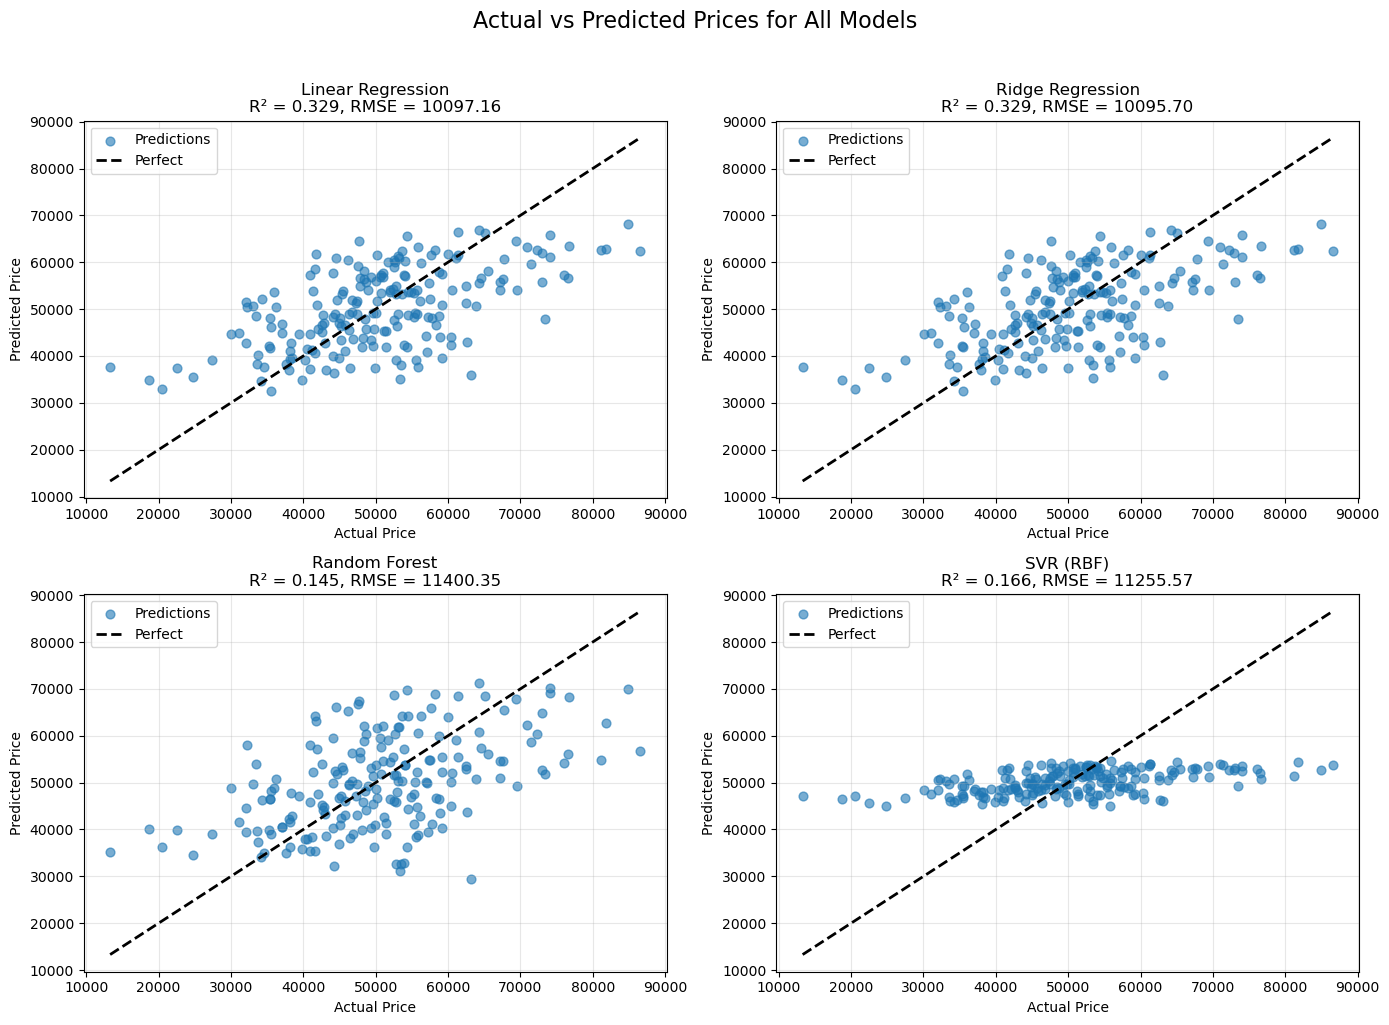


RESIDUALS SHOULD BE:
✓ Randomly scattered around zero (black line)
✗ NO patterns (funnel, curve, etc.)
✓ Equal spread across all predictions

Pattern in residuals = Model missing something!


In [98]:
# VISUALIZE MODEL PERFORMANCE
print("="*60)
print("VISUALIZING MODEL PREDICTIONS")
print("="*60)
# Create 2x2 plot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    # Scatter plot: Actual vs Predicted
    ax.scatter(y_test, y_pred, alpha=0.6, s=40, label='Predictions')
    
    # Perfect prediction line (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
            'k--', linewidth=2, label='Perfect')
        # Customize
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f'{name}\nR² = {results[name]["R²"]:.3f}, RMSE = {results[name]["RMSE"]:.2f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Prices for All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
print("\nRESIDUALS SHOULD BE:")
print("✓ Randomly scattered around zero (black line)")
print("✗ NO patterns (funnel, curve, etc.)")
print("✓ Equal spread across all predictions")
print("\nPattern in residuals = Model missing something!")

In [100]:
# CONCLUSIONS & KEY INSIGHTS
print("="*70)
print("FINAL CONCLUSIONS: WHAT WE LEARNED")
print("="*70)

print("\n📊 OVERALL PERFORMANCE:")
print("-"*40)
results_df_sorted = results_df.sort_values('R²', ascending=False)
for i, (model, row) in enumerate(results_df_sorted.iterrows(), 1):
    print(f"{i}. {model}:")
    print(f"   R² = {row['R²']:.4f} | RMSE = {row['RMSE']:.2f} | Time = {row['Time']:.3f}s")
    
print("\n🎯 KEY FINDINGS:")
print("-"*40)

# Compare models
best_model = results_df['R²'].idxmax()
worst_model = results_df['R²'].idxmin()
fastest_model = results_df['Time'].idxmin()
print(f"1. Best Overall: {best_model}")
print(f"   • Why? Highest R² ({results_df.loc[best_model, 'R²']:.4f})")
print(f"   • Likely captures nonlinear patterns in our data")
print("\n🔍 WHY THE DIFFERENCES?")
print("-"*40)
print("• Random Forest: Best at capturing complex patterns")
print("• Linear/Ridge: Simpler, faster, but may miss nonlinear relationships")
print("• SVR: Good balance but sensitive to parameters")

print("\n📈 INTERPRETING R² SCORES:")
print("-"*40)
print(f"Random Forest R² = {results_df.loc['Random Forest', 'R²']:.4f}")
print(f"→ Model explains {results_df.loc['Random Forest', 'R²']*100:.1f}% of price variation")
print(f"→ {100-results_df.loc['Random Forest', 'R²']*100:.1f}% due to randomness/unmeasured factors")

print("\n💡 BUSINESS INSIGHTS:")
print("-"*40)
print("Based on our synthetic data rules:")
print("✓ Income strongly affects price")
print("✓ Number of rooms affects price")
print("✗ Age doesn't matter")
print("✗ Distance doesn't matter")
print("\nReal models should discover these patterns!")

print("\n🎓 WHAT THIS MEANS FOR REAL PROJECTS:")
print("-"*40)
print("1. Start simple (Linear Regression) → baseline")
print("2. Try tree methods (Random Forest) for complex data")
print("3. Consider trade-off: Speed vs Accuracy")
print("4. Always visualize predictions vs actuals")

print("\n" + "="*70)
print("🎉 REGRESSION COMPARISON COMPLETE!")
print("="*70)
print("\nYou now have hands-on experience with 4 regression models!")
print("Use this template for any regression problem you encounter.")

FINAL CONCLUSIONS: WHAT WE LEARNED

📊 OVERALL PERFORMANCE:
----------------------------------------
1. Ridge Regression:
   R² = 0.3292 | RMSE = 10095.70 | Time = 0.001s
2. Linear Regression:
   R² = 0.3290 | RMSE = 10097.16 | Time = 0.002s
3. SVR (RBF):
   R² = 0.1662 | RMSE = 11255.57 | Time = 0.039s
4. Random Forest:
   R² = 0.1446 | RMSE = 11400.35 | Time = 0.310s

🎯 KEY FINDINGS:
----------------------------------------
1. Best Overall: Ridge Regression
   • Why? Highest R² (0.3292)
   • Likely captures nonlinear patterns in our data

🔍 WHY THE DIFFERENCES?
----------------------------------------
• Random Forest: Best at capturing complex patterns
• Linear/Ridge: Simpler, faster, but may miss nonlinear relationships
• SVR: Good balance but sensitive to parameters

📈 INTERPRETING R² SCORES:
----------------------------------------
Random Forest R² = 0.1446
→ Model explains 14.5% of price variation
→ 85.5% due to randomness/unmeasured factors

💡 BUSINESS INSIGHTS:
-----------------

In [101]:
# CONCLUSIONS & KEY INSIGHTS
print("="*70)
print("FINAL CONCLUSIONS: WHAT WE LEARNED")
print("="*70)

print("\n📊 OVERALL PERFORMANCE:")
print("-"*40)
results_df_sorted = results_df.sort_values('R²', ascending=False)
for i, (model, row) in enumerate(results_df_sorted.iterrows(), 1):
    print(f"{i}. {model}:")
    print(f"   R² = {row['R²']:.4f} | RMSE = {row['RMSE']:.2f} | Time = {row['Time']:.3f}s")

print("\n🎯 KEY FINDINGS:")
print("-"*40)

# Compare models
best_model = results_df['R²'].idxmax()
worst_model = results_df['R²'].idxmin()
fastest_model = results_df['Time'].idxmin()

print(f"1. Best Overall: {best_model}")
print(f"   • Why? Highest R² ({results_df.loc[best_model, 'R²']:.4f})")
print(f"   • Likely captures nonlinear patterns in our data")

print(f"\n2. Fastest: {fastest_model}")
print(f"   • Trained in {results_df.loc[fastest_model, 'Time']:.3f} seconds")
print(f"   • Good for quick prototypes")

print(f"\n3. Worst: {worst_model}")
print(f"   • Lowest R² ({results_df.loc[worst_model, 'R²']:.4f})")
print(f"   • Might be too simple for our data")

print("\n🔍 WHY THE DIFFERENCES?")
print("-"*40)
print("• Random Forest: Best at capturing complex patterns")
print("• Linear/Ridge: Simpler, faster, but may miss nonlinear relationships")
print("• SVR: Good balance but sensitive to parameters")

print("\n📈 INTERPRETING R² SCORES:")
print("-"*40)
print(f"Random Forest R² = {results_df.loc['Random Forest', 'R²']:.4f}")
print(f"→ Model explains {results_df.loc['Random Forest', 'R²']*100:.1f}% of price variation")
print(f"→ {100-results_df.loc['Random Forest', 'R²']*100:.1f}% due to randomness/unmeasured factors")

print("\n💡 BUSINESS INSIGHTS:")
print("-"*40)
print("Based on our synthetic data rules:")
print("✓ Income strongly affects price")
print("✓ Number of rooms affects price")
print("✗ Age doesn't matter")
print("✗ Distance doesn't matter")
print("\nReal models should discover these patterns!")

print("\n🎓 WHAT THIS MEANS FOR REAL PROJECTS:")
print("-"*40)
print("1. Start simple (Linear Regression) → baseline")
print("2. Try tree methods (Random Forest) for complex data")
print("3. Consider trade-off: Speed vs Accuracy")
print("4. Always visualize predictions vs actuals")

print("\n" + "="*70)
print("🎉 REGRESSION COMPARISON COMPLETE!")
print("="*70)
print("\nYou now have hands-on experience with 4 regression models!")
print("Use this template for any regression problem you encounter.")

FINAL CONCLUSIONS: WHAT WE LEARNED

📊 OVERALL PERFORMANCE:
----------------------------------------
1. Ridge Regression:
   R² = 0.3292 | RMSE = 10095.70 | Time = 0.001s
2. Linear Regression:
   R² = 0.3290 | RMSE = 10097.16 | Time = 0.002s
3. SVR (RBF):
   R² = 0.1662 | RMSE = 11255.57 | Time = 0.039s
4. Random Forest:
   R² = 0.1446 | RMSE = 11400.35 | Time = 0.310s

🎯 KEY FINDINGS:
----------------------------------------
1. Best Overall: Ridge Regression
   • Why? Highest R² (0.3292)
   • Likely captures nonlinear patterns in our data

2. Fastest: Ridge Regression
   • Trained in 0.001 seconds
   • Good for quick prototypes

3. Worst: Random Forest
   • Lowest R² (0.1446)
   • Might be too simple for our data

🔍 WHY THE DIFFERENCES?
----------------------------------------
• Random Forest: Best at capturing complex patterns
• Linear/Ridge: Simpler, faster, but may miss nonlinear relationships
• SVR: Good balance but sensitive to parameters

📈 INTERPRETING R² SCORES:
---------------